Расчеты по написанию рукописи о первом приближении асимптотического метода в скалярном представлении (решение ОДУ 2го порядка)

NOTE: код программы ниже соответствует коммиту https://github.com/Bannigd/PYAWM/tree/369abcdf2e87e50e6909a0ab8de6bc8a259a03de/pyawm/main.py]
python 3.13.5
sympy 1.14.0

In [7]:
import sympy as sp
from sympy.solvers.ode.systems import dsolve_system
from sympy.vector import CoordSys3D, curl, Del
from sympy.utilities.autowrap import autowrap

from itertools import product

execfile("../pyawm/preview_wrappers.py")

def list_subs(eqs: list, subs: dict, eval=False):
    if eval:
        return [eq.subs(subs).expand().simplify() for eq in eqs]
    return [eq.subs(subs) for eq in eqs]

def dict_subs(eqs: dict, subs: dict, *, eval=False, both=False):
    res = dict()
    for k, v in eqs.items():
        res[k.subs(subs) if both else k] = v.subs(subs).expand().simplify() if eval else v.subs(subs)
    return res

# TODO: provide additional info about vars/functions
t       = sp.Symbol("t")
x       = sp.Symbol("x")
y       = sp.Symbol("y")
z       = sp.Symbol("z")
phi     = sp.Function("varphi")(y,z)
eta     = sp.Function("eta")(y,z)
gamma   = sp.Function("gamma")(y,z)
c       = sp.Symbol("c")
mu      = sp.Symbol("mu")
epsilon = sp.Symbol("varepsilon")
omega   = sp.Symbol("omega")

from enum import Enum

class Layer(Enum):
    # strings will be used as indexes in sympy object names
    COVER      = "c"
    FILM       = "f"
    LENS       = "l"
    SUBSTRATE  = "s"

    # Define aliases as class attributes
    C = COVER
    F = FILM
    L = LENS
    S = SUBSTRATE

class Waveguide:
    """
    Description of waveguide structure. Here we should specifty:
    1. Non-zero field components from (x,y,z)
    2. Declare how they are compared in terms of orders of magnitude
    3. Geometry: how many layers, their name/indexes, function that describes their profile
    4. Phase `phi` with correct arguments 
    """
    def __init__(self, field_vars, layers, geometry, phi_vars):
        self.field_vars = field_vars
        self.layers        = layers
        self.geometry      = geometry
        self.phi_vars      = phi_vars
        self.phi           = phi.func(*phi_vars)

        
class Domain:
    def __init__(self, WG: Waveguide):
        self.WG = WG
        self.E = sp.Function("E")
        self.H = sp.Function("H")
        self.U = [self.E, self.H]
 
        for comp in [x,y,z]:
            setattr(self, self.E.name+comp.name, sp.Function(f"{self.E}^{comp}")(x,y,z,t))
            setattr(self, self.H.name+comp.name, sp.Function(f"{self.H}^{comp}")(x,y,z,t))
       
    def construct_series_sum(self, order):
        # creating Ex0, Ey0, ..., Hx0, ... class attributes for easy access
        U_comps = [(U.name, i.name) for U, i in product(self.U, [x,y,z])]
        for U, comp in U_comps:
            for s in range(order+1):
                setattr(self, f"{U}{comp}{s}",sp.Function(f"{U}^{comp}_{s}")(x,y,z))
                
        for U, comp in U_comps:
            series_attr_name = f"{U}{comp}_series" 
            setattr(self, series_attr_name, [])
            for s in range(order+1):
                tmp = 0
                for k in range(s+1):
                    F = (getattr(self, f"{U}{comp}{k}")) # e.g. Ex0
                    tmp += F*(sp.I*omega)**(-k)
                getattr(self, series_attr_name).append(tmp)
        

    def construct_maxwell_equations(self):
        """
        creates Maxwell's equations in differential form before any manipulations
        """
        R = CoordSys3D("R")

        # Ex(R.x,R.y,R.z)*R.i + ...
        for comp in [x,y,z]:
            setattr(self, self.E.name+comp.name, sp.Function(f"{self.E}^{comp}")(x,y,z,t))
            setattr(self, self.H.name+comp.name, sp.Function(f"{self.H}^{comp}")(x,y,z,t))

        vfield_E = sum(
            [F.func(R.x, R.y, R.z, t)*unit
             for F, comp, unit in zip([self.Ex, self.Ey, self.Ez], [x, y, z], [R.i, R.j, R.k])], 0*R.i)

        vfield_H = sum(
            [F.func(R.x, R.y, R.z, t)*unit
             for F, comp, unit in zip([self.Hx, self.Hy, self.Hz], [x, y, z], [R.i, R.j, R.k])], 0*R.i)

        curl_E = curl(vfield_E) + mu / c      * vfield_H.diff(t)
        curl_H = curl(vfield_H) - epsilon / c * vfield_E.diff(t)

        # cleaning equations
        eqs = list_subs(list(curl_E.doit().to_matrix(R)) +
                        list(curl_H.doit().to_matrix(R)),
                        {R.x:x,R.y:y,R.z:z})

        return eqs

    def construct_equations_wrt_series(self, order):
        self.construct_series_sum(order)
        eqs = list_subs(self._maxwell_equations,
                          {
                              self.Ex: self.Ex_series[order]*sp.exp(sp.I*omega*t-sp.I*omega/c*phi),
                              self.Ey: self.Ey_series[order]*sp.exp(sp.I*omega*t-sp.I*omega/c*phi),
                              self.Ez: self.Ez_series[order]*sp.exp(sp.I*omega*t-sp.I*omega/c*phi),
                              self.Hx: self.Hx_series[order]*sp.exp(sp.I*omega*t-sp.I*omega/c*phi),
                              self.Hy: self.Hy_series[order]*sp.exp(sp.I*omega*t-sp.I*omega/c*phi),
                              self.Hz: self.Hz_series[order]*sp.exp(sp.I*omega*t-sp.I*omega/c*phi),
                          })

        # TODO: подумать альтернативный способ сократить экспоненту, чтобы не нужно было явно выписывать формулу
        eqs = list(map(lambda eq: eq/sp.exp(sp.I * omega * t - sp.I * omega / c * phi), eqs))
        eqs = list(map(lambda eq: eq.doit().expand(), eqs))
        return eqs


    def update_general_solution_form_wrt_waveguide(self, eqs, order):
        """
        substitute (x,y,z)->WG.field_vars, phi->WG.phi, 
        """
        sym_subs = dict()
        sym_subs[phi] = self.WG.phi

        # changes (x,y,z)->WG.field_vars and changes corresponding class attributes
        for U, comp, s in product(self.U, [x,y,z], range(0,order+1)):
            func = getattr(self, U.name+comp.name+str(s))
            sym_subs[func] = func.func(*self.WG.field_vars)
            setattr(self, U.name+comp.name+str(s), sym_subs[func])

        
        # derivatives are zeroed only for d/dy and d/dz for highest components
        for U, comp in product(self.U, [x,y,z]):
            func = getattr(self, U.name+comp.name+str(order))
            sym_subs[sp.Derivative(func, y)] = 0
            sym_subs[sp.Derivative(func, z)] = 0

        return list_subs(eqs, sym_subs)
        

    def layered_sols(self, sols, layer: Layer, order) -> list:
        # NOTE: in some layers we make a substitution of x->x-h_i(z). 
        # The layers to do this subs are chosen manually, and for now i dont know how to automate this criteria.
        # Maybe just provide a flag for each layer to do or not to do this substitution.

        # 2. Zero coeffs at exp(-<...>) or exp(<..>) governed by asymptotic conditions on infty
        match layer:
            case Layer.COVER:
                sols = {k: v.replace(sp.exp( x*gamma.func(*self.WG.phi.args)), 0) for k, v in sols.items()}
            case Layer.SUBSTRATE:
                sols = {k: v.replace(sp.exp(-x*gamma.func(*self.WG.phi.args)), 0) for k, v in sols.items()}

            # For film and lens layers are closed, so asympotic conditions dont apply
            case Layer.FILM | Layer.LENSE:
                pass
                


        # 1. Subs functions and constants in accordance to layer passed
        sym_subs = dict()
        # constants
        setattr(self, mu.name+"_"+layer.value, sp.Symbol(f"{mu.name}_{layer.value}"))
        setattr(self, epsilon.name+"_"+layer.value, sp.Symbol(f"{epsilon.name}_{layer.value}"))
        setattr(self, eta.name+"_"+layer.value, sp.Function(f"{eta.name}_{layer.value}")(*self.WG.phi_vars))
        setattr(self, gamma.name+"_"+layer.value, sp.Function(f"{gamma.name}_{layer.value}")(*self.WG.phi_vars))
        sym_subs[mu]      = getattr(self, mu.name+"_"+layer.value)
        sym_subs[epsilon] = getattr(self, epsilon.name+"_"+layer.value)
        sym_subs[eta]     = getattr(self, eta.name+"_"+layer.value)
        sym_subs[gamma]   = getattr(self, gamma.name+"_"+layer.value)
        
        for U, comp, s in product(self.U, [x,y,z], range(order+1)):
            func = getattr(self, U.name+comp.name+str(s)) 
            setattr(self, U.name+comp.name+str(s)+layer.value, sp.Function(f"{U}^{{{comp.name},{layer.value}}}_{s}")(*func.args))
            sym_subs[func] = getattr(self, U.name+comp.name+str(s)+layer.value)

        sols = dict_subs(sols, sym_subs, both=True)

        # 3. Subs x->x-h_i in layers h != 0
        match layer:
            case Layer.COVER:
                # TODO: this is ugly
                if Layer.LENS in self.WG.layers:
                    sols = dict_subs(sols, {x: x-sp.Function(f"h_{{{Layer.LENS.value}}}")(*self.WG.phi_vars)})
                else:
                    sols = dict_subs(sols, {x: x-sp.Function(f"h_{{{Layer.FILM.value}}}")(*self.WG.phi_vars)})
            case Layer.LENS:
                sols = dict_subs(sols, {x: x-sp.Function(f"h_{{{Layer.FILM.value}}}")(*self.WG.phi_vars)})
            case Layer.FILM:
                sols = dict_subs(sols, {x: x-sp.Function(f"h_{{{Layer.SUBSTRATE.value}}}")(*self.WG.phi_vars)})
            case Layer.SUBSTRATE:
                # do nothing
                pass

        # 4. Subs C1, C2,.. with lettered coeffs

        C_numbers = sp.symbols("C1:5")
        sym_coeffs = list()
        for letter in "ABCD":
            setattr(self, letter+layer.value+str(order), sp.Symbol(f"{letter}^{layer.value}_{order}"))
            sym_coeffs.append(getattr(self, letter+layer.value+str(order)))

        setattr(self, f"sym_coeffs{order}", sym_coeffs)
        sols = dict_subs(sols, {k: v for k, v in zip(C_numbers, sym_coeffs, strict=True)})

        return sols

    def solve_general_form_zero(self):
        """
        Main method for solving awm problem in zero order. Does a lot of things inside.
        """
        order = 0
        self._maxwell_equations = self.construct_maxwell_equations()

        self.eqs0 = self.construct_equations_wrt_series(order)
        self.eqs0 = self.update_general_solution_form_wrt_waveguide(self.eqs0, order)

        self.diff_eqs0 = [eq for eq in self.eqs0 if eq.find(sp.Derivative(sp.Wild('w'), x))]
        self.alg_eqs0  = [eq for eq in self.eqs0 if not eq.find(sp.Derivative(sp.Wild('w'), x))]

        # TODO: is it too "hard-coded"? Maybe its fine
        self.alg_sols0 = {self.Hx0: sp.solve(self.alg_eqs0[0], self.Hx0)[0],
                          self.Ex0: sp.solve(self.alg_eqs0[1], self.Ex0)[0]}

        # temporary substitute all functions' arguments (x,y,z) -> (x)
        sym_func_subs = dict()
        for U, comp in product(self.U, [y, z]):
            func = getattr(self, U.name+comp.name+str(order))
            sym_func_subs[func] = func.func(x)

        temp_diff_eqs = list_subs(self.diff_eqs0, self.alg_sols0)
        temp_diff_eqs = list(map(lambda eq: eq.doit(), temp_diff_eqs)) # auto reduces d/dy phi(z) 
        temp_diff_eqs = list_subs(temp_diff_eqs, sym_func_subs)
        
        self.diff_sols0 = dsolve_system(
            temp_diff_eqs,
            funcs=list(sym_func_subs.values()),
            t=x,
        )[0]

        self.diff_sols0 = list_subs(self.diff_sols0, {v: k for k,v in sym_func_subs.items()})

        self.sols0 = self.alg_sols0.copy()
        for sol in self.diff_sols0:
            self.sols0[sol.lhs] = sol.rhs

        # TODO: generalize for lens problem 
        self.sols0 = dict_subs(
            self.sols0,
            {
                omega / c * sp.sqrt(-epsilon * mu + sp.diff(self.WG.phi, z) ** 2): gamma,
                -epsilon * mu + sp.diff(self.WG.phi, z) ** 2: eta
            },
            eval=False,
        )

        self.sols0[self.Ex0] = self.sols0[self.Ex0].subs(self.sols0)
        self.sols0[self.Hx0] = self.sols0[self.Hx0].subs(self.sols0)
        
        # multiple by a denominator to simplify form
        self.sols0 = dict_subs(
            self.sols0,
            {
                sp.Symbol("C1"): sp.Symbol("C1") * sp.sqrt(eta),
                sp.Symbol("C2"): sp.Symbol("C2") * sp.sqrt(eta),
                sp.Symbol("C3"): sp.Symbol("C3") * epsilon,
                sp.Symbol("C4"): sp.Symbol("C4") * epsilon,
            },
            eval=False,
        )
        # preview_collection(self.sols0)

        # Construct solution in each layer
        for layer in self.WG.layers:
            setattr(self, "sols0"+"_"+layer.value, self.layered_sols(self.sols0, layer, order))


    def construct_boundary_equations(self, order):
        R = CoordSys3D("")
        h_vars = [getattr(R, var.name) for var in self.WG.phi_vars]
        field_subs = {getattr(R, comp.name): comp for comp in self.WG.field_vars}

        self.boundary_eqs = list()
        for left_layer, right_layer, border_func in self.WG.geometry:
            vE_left  = sum([
                field_axis*getattr(self, f"E{comp}{order}{left_layer.value}").func(*field_subs.keys()) 
                for comp, field_axis in zip([x, y, z], [R.i, R.j, R.k])], 0*R.i
                           )
            vE_right  = sum([
                field_axis*getattr(self, f"E{comp}{order}{right_layer.value}").func(*field_subs.keys()) 
                for comp, field_axis in zip([x, y, z], [R.i, R.j, R.k])], 0*R.i
                           )
            vH_left  = sum([
                field_axis*getattr(self, f"E{comp}{order}{left_layer.value}").func(*field_subs.keys()) 
                for comp, field_axis in zip([x, y, z], [R.i, R.j, R.k])], 0*R.i
                           )
            vH_right  = sum([
                field_axis*getattr(self, f"E{comp}{order}{right_layer.value}").func(*field_subs.keys()) 
                for comp, field_axis in zip([x, y, z], [R.i, R.j, R.k])], 0*R.i
                           )

            delop = Del()
            normal = delop(R.x-border_func(*h_vars)).doit()
            eq = (normal.cross(vE_left)-normal.cross(vE_right)).subs(field_subs)
            self.boundary_eqs.extend([eq.components[arg] for arg in [R.j, R.k]])
            eq = (normal.cross(vH_left)-normal.cross(vH_right)).subs(field_subs)
            self.boundary_eqs.extend([eq.components[arg] for arg in [R.j, R.k]])
                        

    def solve_arbitrary_constants(self):
        raise NotImplementedError("")

## Нулевое приближение

In [8]:
# 2d smoothly irregular waveguide, ref: https://indico.jinr.ru/event/4467/contributions/28934/attachments/20530/35707/starikov_mmcp2024.pdf
field_vars = [x, z]
# TODO: change name
phi_vars = [z] # and for h
layers = [
    Layer.SUBSTRATE,
    Layer.FILM,
    Layer.COVER,
]

# TODO: think about autogenerating h function and provide only layers.
# Less manual work and should be easier to maintain
geometry = [
    (Layer.FILM,      Layer.COVER, sp.Function(f"h_{{{Layer.FILM.value}}}")),
    (Layer.SUBSTRATE, Layer.FILM,  sp.Function(f"h_{{{Layer.SUBSTRATE.value}}}"))
]
horn = Waveguide(field_vars, layers, geometry, phi_vars)
d = Domain(horn)
d.solve_general_form_zero()
d.construct_boundary_equations(0)

In [19]:
sp.init_printing()

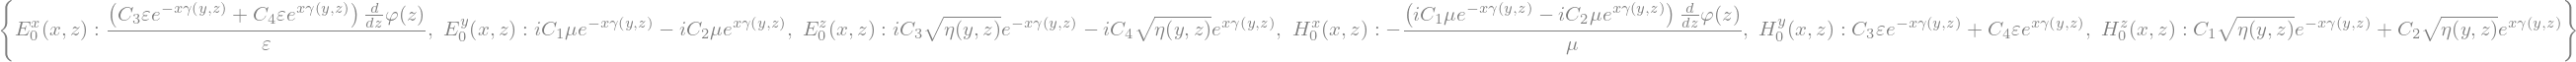

In [23]:
display(d.sols0)

### Группируем уравнения по ТЕ- и ТМ-модам

In [61]:
d.eqs0 = list(map(lambda eq: eq.doit(), d.eqs0))

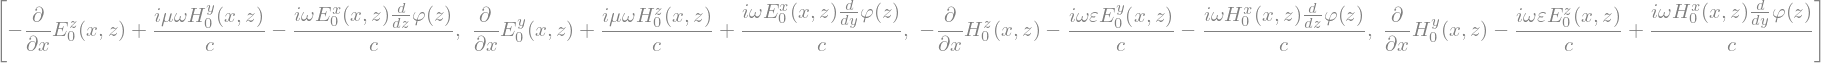

In [68]:
d.diff_eqs0

In [74]:
eqs0_TE = [eq for eq in d.eqs0 if eq.has_xfree({d.Ey0, d.Hx0, d.Hz0})]
eqs0_TM = [eq for eq in d.eqs0 if eq.has_xfree({d.Hy0, d.Ex0, d.Ez0})]

In [77]:
eqs0_TE

NameError: name 'k' is not defined

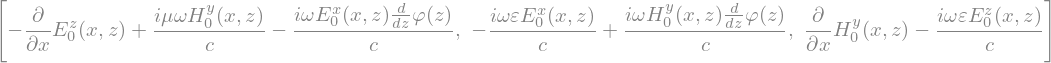

In [76]:
eqs0_TM

In [78]:
k = sp.Symbol("k")
eqs0_TE = list_subs(eqs0_TE, {omega/c:k},eval=True)
eqs0_TM = list_subs(eqs0_TM, {omega/c:k},eval=True)

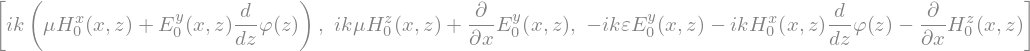

In [79]:
eqs0_TE

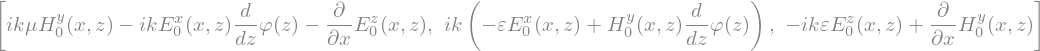

In [80]:
eqs0_TM

### Приводим к системе ОДУ второго порядка

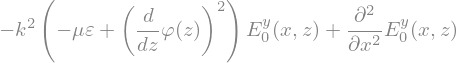

In [118]:
eq_2nd_TE = (eqs0_TE[2]*(-k*mu/sp.I))\
    .subs({d.Hz0: sp.solve(eqs0_TE[1], d.Hz0)[0], d.Hx0: sp.solve(eqs0_TE[0], d.Hx0)[0]})\
    .doit()\
    .expand()\
    .collect(d.Ey0,sp.combsimp)
eq_2nd_TE

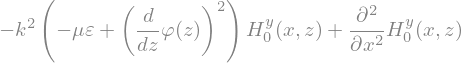

In [132]:
eq_2nd_TM = (eqs0_TM[0]*(k*epsilon/sp.I))\
    .subs({d.Ex0: sp.solve(eqs0_TM[1], d.Ex0)[0], d.Ez0: sp.solve(eqs0_TM[2], d.Ez0)[0]})\
    .doit()\
    .expand()\
    .collect(d.Hy0,sp.combsimp)
eq_2nd_TM

### Формулируем вспомогательную спектральную задачу

In [133]:
beta0 = sp.Function("beta0")(z)

In [190]:
eq_2nd_TE = eq_2nd_TE.subs(sp.diff(d.WG.phi, z), beta0)
eq_2nd_TM = eq_2nd_TM.subs(sp.diff(d.WG.phi, z), beta0)
eqs0_TE = list_subs(eqs0_TE, {sp.diff(d.WG.phi, z): beta0})
eqs0_TM = list_subs(eqs0_TM, {sp.diff(d.WG.phi, z): beta0})

In [202]:
sols0_TE = {
    d.Ey0: sp.dsolve(eq_2nd_TE.subs(d.Ey0, d.Ey0.func(x)), d.Ey0.func(x)).rhs,
}
sols0_TE[d.Hx0] = sp.solve(eqs0_TE[0].subs(sols0_TE), d.Hx0)[0].expand()
sols0_TE[d.Hz0] = sp.solve(eqs0_TE[1].subs(sols0_TE), d.Hz0)[0].expand()

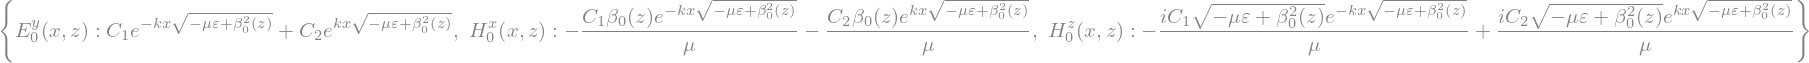

In [203]:
sols0_TE

In [204]:
sols0_TM = {
    d.Hy0: sp.dsolve(eq_2nd_TM.subs(d.Hy0, d.Hy0.func(x)), d.Hy0.func(x)).rhs
}
sols0_TM[d.Ex0] = sp.solve(eqs0_TM[1].subs(sols0_TM), d.Ex0)[0].expand()
sols0_TM[d.Ez0] = sp.solve(eqs0_TM[2].subs(sols0_TM), d.Ez0)[0].expand()

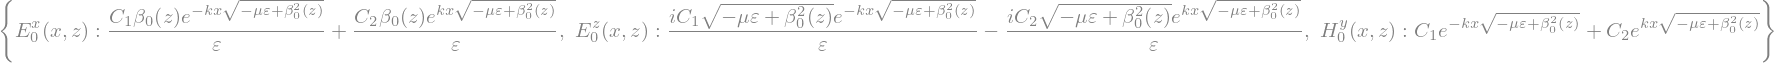

In [205]:
sols0_TM

In [208]:
print(latex(sols0_TE))

\left\{ E^{y}_{0}{\left(x,z \right)} : C_{1} e^{- k x \sqrt{- \mu \varepsilon + \beta_{0}^{2}{\left(z \right)}}} + C_{2} e^{k x \sqrt{- \mu \varepsilon + \beta_{0}^{2}{\left(z \right)}}}, \  H^{x}_{0}{\left(x,z \right)} : - \frac{C_{1} \beta_{0}{\left(z \right)} e^{- k x \sqrt{- \mu \varepsilon + \beta_{0}^{2}{\left(z \right)}}}}{\mu} - \frac{C_{2} \beta_{0}{\left(z \right)} e^{k x \sqrt{- \mu \varepsilon + \beta_{0}^{2}{\left(z \right)}}}}{\mu}, \  H^{z}_{0}{\left(x,z \right)} : - \frac{i C_{1} \sqrt{- \mu \varepsilon + \beta_{0}^{2}{\left(z \right)}} e^{- k x \sqrt{- \mu \varepsilon + \beta_{0}^{2}{\left(z \right)}}}}{\mu} + \frac{i C_{2} \sqrt{- \mu \varepsilon + \beta_{0}^{2}{\left(z \right)}} e^{k x \sqrt{- \mu \varepsilon + \beta_{0}^{2}{\left(z \right)}}}}{\mu}\right\}
